# Module 5 - Bivariate analysis: qualitative vs quantitative

In this module, we discuss the case where the independent variable is qualitative and the dependent is quantitative. Some typical examples of research question in this case:

- Within a certain species of animals, are male individuals significantly larger than females?
- Is there a gender gap in salaries?
- Does a new vaccine protect against the disease like it's supposed to?
- Does a certain study method like "retrieval practice" actually improve learning outcomes (i.e. student's grades)?

In this course, we only treat the case where we compare two groups. There are methods to compare more than two groups (e.g. the ANOVA test), but those are beyond the scope of this course.  

## Learning goals

By the end of this module, you should be able to:

- Understand the definitions and terminology (indicated with 💡) used in this notebook
- Visualize data for these types of research questions with appropriate plots: grouped boxplot, grouped violin plot, density plot, or (when appropriate) bar plot with error bars
- Perform a two-sample $t$-test to determine if the difference between the two groups is statistically significant
- Calculate the effect size (Cohen's $d$) to understand the practical significance of the results

In [ ]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

## Data visualisation

For data visualisation, we can use the same graph types as for the case of one quantitative variable, but we need to group the data by the categories of the qualitative variable. This allows us to visually compare the distributions of the quantitative variable across the different groups.

The following chart types may be appropriate for this type of data:

- grouped boxplot or violin plot
- grouped density (kde-)plot
- bar chart with error bars (e.g. standard deviation, *only for data that is normally distributed*)

We'll use the dataset `tips`, included in the Seaborn package to illustrate these.

### Boxplot or violin plot

For a horizontal boxplot, map the independent (qualitative) variable on the Y-axis and the dependent (quantitative) variable on the X-axis. Swap for a vertical plot.

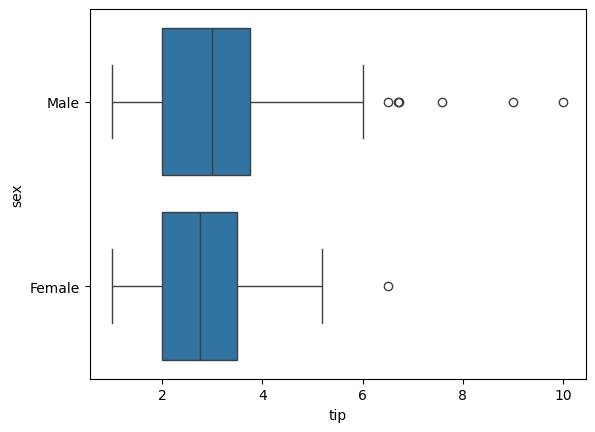

In [ ]:
tips = sns.load_dataset("tips")
sns.boxplot(data=tips, x='tip', y='sex');

If there's a lot of overlap between the (boxes of the) different groups, like in this example, this indicates that the relation between both variables is weak or non-existent.

The violin plot works similarly:

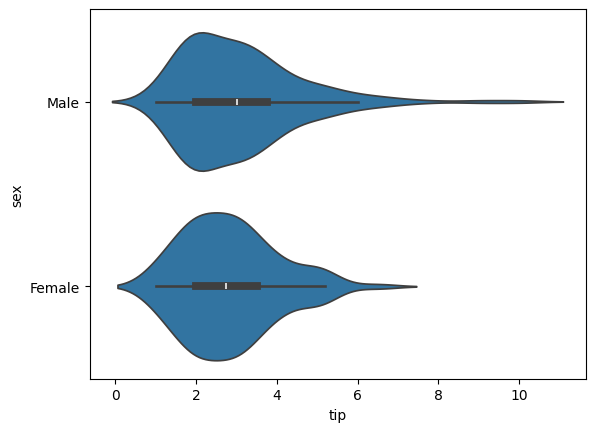

In [ ]:
sns.violinplot(data=tips, x='tip', y='sex');

### Density plot

For a density (kernel density estimate) plot, map the independent (qualitative) variable on the `hue` attribute and the dependent variable on the X-axis.

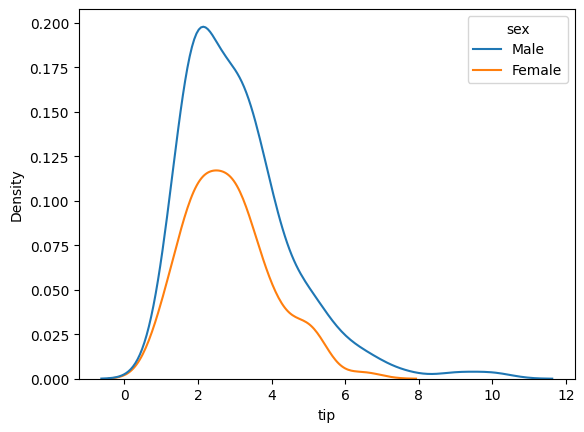

In [ ]:
sns.kdeplot(data=tips, hue='sex', x='tip');

The density curves of the two groups in this example are completely overlapping, which again indicates that there is no relation between both variables.

### Bar chart with error bars

Another chart type that is often used for this type of data is a *bar plot of the sample mean of each group*. However, watch out with this. Only showing the sample mean in a chart is insufficient to determine whether any difference between groups is significant.

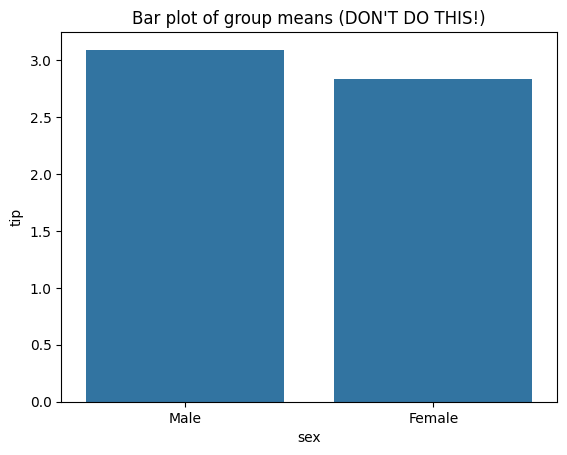

In [ ]:
sns.barplot(data=tips, x='sex', y='tip', errorbar=None).set_title('Bar plot of group means (DON\'T DO THIS!)');

The example above suggests that the average tip amount is higher for the male group than for the female group. With the other chart types, we already saw that there is a lot of overlap, but that information is lost in this bar chart.

A chart should also show the *dispersion* in the data set. This can be visualized using error bars.

In the example below, the parameter `errorbar='sd'` (in older versions of Seaborn: `ci='sd'`) will show the standard deviation:

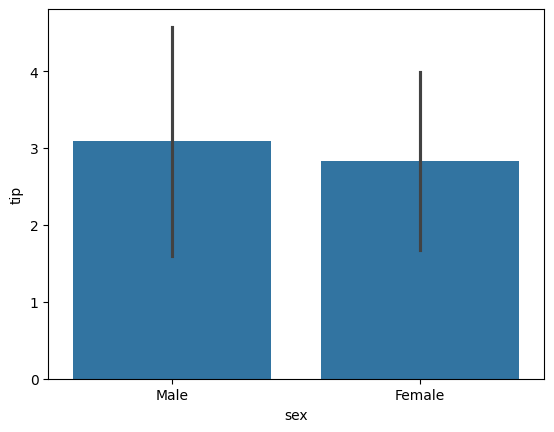

In [ ]:
sns.barplot(data=tips, x='sex', y='tip', errorbar='sd');

Again, if there's a lot of overlap between the error bars, this indicates that there is no (or only a small) association between the variables.

**Remark** that this type of chart is only useful if the variable is *normally distributed*. In this dataset with a lot of outliers (see the boxplot from earlier), the symmetrical error bars *do not correctly represent* how the data is distributed. Usually a boxplot or density plot is more appropriate.

## Introduction
Earlier (Chapter 3), we saw how to apply the $t$-test to verify a statement about the sample mean of a small sample, or when the population standard deviation is unknown. The $t$-test can also be used to compare two samples.
So:  
* We use the one sample t-test when we want to compare the mean of a sample with a known reference mean.
* We use the t-test for independent samples when we want to compare the means of two independent groups or samples. We want to know if there is a significant difference between these means.
* We use the Paired Samples t-Test is to compare the means of two dependent groups. In a dependent sample (paired sample), the measured values are available in pairs. The pairs are created, for example, by repeated measurements on the same persons.

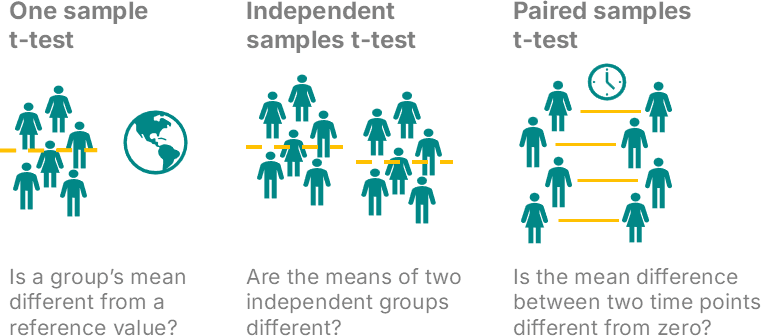




First, we will look at the case of 💡**independent samples** that were taken separately.

## The t-test for two independent samples
### Example: clinical trial

In a clinical trial, researchers want to determine whether some new drug has a reduced reaction speed, i.e. a higher reaction time,  as a side effect.

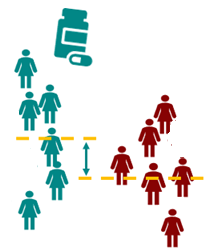

In our example six participants received the drug (treatment group), while six others received a placebo (control group). Their response time to a stimulus was then measured (in ms). We want to investigate whether there are significant differences between the treatment and control groups.

The response time measurements are given below:

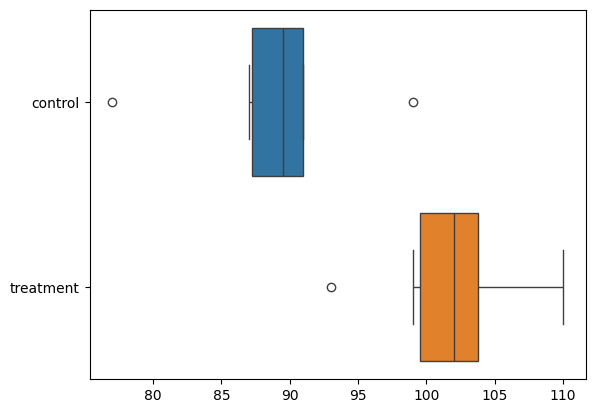

In [ ]:
# Sample:
control = np.array([91, 87, 99, 77, 88, 91])
treatment = np.array([101, 110, 103, 93, 99, 104])
# Visualization:
sns.boxplot(
    data=pd.DataFrame({'control': control, 'treatment': treatment}),
    orient='h');

The population mean for patients in the control group is notated $\mu_1$, for those in the treatment group $\mu_2$.

The test procedure runs as follows:

1. Formulate the hypotheses:

      - $H_0$: $\mu_1 - \mu_2 = 0$ (reaction time is the same in both groups)
      - $H_1$: $\mu_1 - \mu_2 < 0$ (reaction time is significantly higher in the treatment group compared to the control group)

2. Choose a significance level $\alpha$ (e.g. 0.05)

3. Calculate the test statistic $t$:

    $$t = \frac{\overline{x_1} - \overline{x_2}}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}.$$

    with $\overline{x_1}$ and $\overline{x_2}$ being the sample means of the two groups, $s_1$ and $s_2$ the sample standard deviations, and $n_1$ and $n_2$ the sample sizes.

In [ ]:
x1 = control.mean()
x2 = treatment.mean()
s1 = control.std(ddof=1)        # control is numpy array => ddof = 1
s2 = treatment.std(ddof=1)      # treatment is numpy array => ddof = 1
n1 = len(control)
n2 = len(treatment)
t = (x1 - x2) / np.sqrt(s1**2/n1 + s2**2/n2)
print(f't = {t:.4f}');

t = -3.4456


In Python, we can use the `ttest_ind()` function from `scipy.stats`. Parameters `a` and `b` are the two groups to be compared. `alternative='less'` indicates that we want to test for the alternative hypothesis that the mean of the control group is less than the mean of the treatment group. Other values for the parameter are `alternative='greater'` or `alternative='two-sided'`.Finally, by setting `equal_var=False`, it is *not* assumed that both groups have the same standard deviation.

In [ ]:
t, p = stats.ttest_ind(a=control, b=treatment, alternative='less', equal_var=False)
print(f't = {t}')
print(f'p = {p}')

t = -3.445612673536487
p = 0.003391230079206901


4. Calculate the $p$-value

    The $p$-value is also emitted by the `ttest_ind()` function (we won't go into how it was calculated exactly). It represents the probability of observing a test statistic as extreme as, or more extreme than, the one calculated from the sample data, assuming that the null hypothesis is true. For this case, $p \approx 0.0034$.

5. Draw a conclusion based on the $p$-value and the significance level $\alpha$.

    The $p$-value is very small ($p < \alpha$), which means that, if the null hypothesis would be correct, it is highly unlikely to observe the differences between the two groups. Consequently, we reject the null hypothesis. Based on the sample, there is reason to conclude that the drug does indeed have a significant impact on reaction speed.

### Example: tips dataset

In the `tips` dataset, do male and female staff get the same tips or is there a significant difference? Take a look at the plot above to make a guess first.

In this case, we perform a *two-sided test*. I.e. we don't have a specific preconception about which group would get higher tips.

In [ ]:
t, p = stats.ttest_ind(alternative='two-sided',
    a=tips.tip[tips.sex == 'Male'],
    b=tips.tip[tips.sex == 'Female'])
print(f't = {t}')
print(f'p = {p}')

t = 1.387859705421269
p = 0.16645623503456755


The $p$ value of 0.166 is quite large ($p > \alpha$), so we do not reject the null hypothesis. On a significance level of e.g. 0.05, the data set does *not* contain evidence that male and female serving staff receive different tips.

## The t-test for paired samples

In this variant of the two-sample $t$-test, a measurement is taken on each element of the sample, one time *before* and one time *after* an intervention. The aim is to determine whether the intervention had a significant effect on the measurement.

### Example: petrol additives

A study examined whether cars that run on petrol with additives also have a lower consumption. Ten cars were first filled with either regular gasoline or gasoline with additives (determined by tossing a coin), after which consumption was measured (expressed in miles per gallon). The cars were then refueled with the other type of petrol and consumption was measured again.

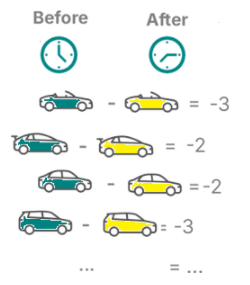

We will use a paired $t$ test to determine whether cars are significantly more economical on gasoline with additives. In a paired $t$-test, we first calculate the difference between each pair of measurements (additives - regular), and then we test whether the mean of these differences is significantly less than zero.

The boxplot below shows the distribution of the differences. The red dashed line indicates a difference of zero (i.e. no effect of the additives). The mean difference is positive, which suggests that the additives do indeed have a positive effect on fuel economy.

Mean difference: 2.00


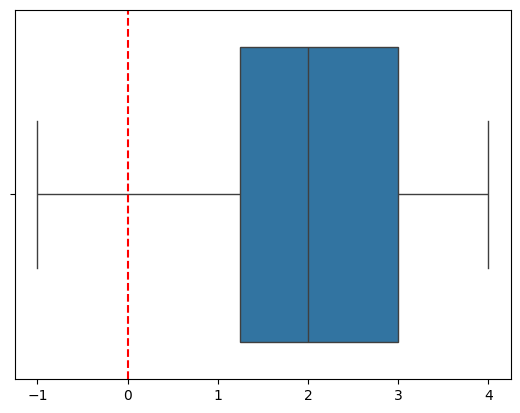

In [ ]:
# Measurements
regular =   np.array([16, 20, 21, 22, 23, 22, 27, 25, 27, 28])
additives = np.array([19, 22, 24, 24, 25, 25, 26, 26, 28, 32])

differences = additives - regular
print(f'Mean difference: {differences.mean():.2f}')
# Visualization
sns.boxplot(differences, orient='h');
plt.axvline(0, color='red', linestyle='--');

In the case of a (left-tailed) paired $t$-test, the hypotheses are formulated as follows:

- $H_0$: $\mu_{X-Y} = 0$
- $H_1$: $\mu_{X-Y} < 0$

With $\mu_{X-Y}$ being the population mean of the differences between the paired measurements.

The test statistic can be calculated with Python function `ttest_rel()` from `scipy.stats`:

In [ ]:
# Paired t-test with ttest_rel()
t, p = stats.ttest_rel(regular, additives, alternative='less')
print(f't = {t}')
print(f'p = {p}')

t = -4.47213595499958
p = 0.00077494295585091


We use `alternative='less'` because we want to check whether the mileage per gallon on regular fuel is smaller than on fuel with additives.

The $p$-value, 0.0007749, is very small. Even with an $\alpha = 0.01$, we can reject the null hypothesis. In conclusion, according to this sample, we have reasons to assume that the fuel with additives indeed leads to significantly lower fuel consumption.



## Effect size

If we want to know whether two groups are significantly different, we can use a statistical test like the two sample $t$-test. The result of a statistical test is generally either "true" or "false", depending on the $p$-value and the chosen significance level.

💡**Effect size** is another metric to express the *magnitude* of the difference between two groups. The effect size can be used in addition to a hypothesis test.

Several definitions of effect size exist, but one of the most commonly used is 💡**Cohen's $d$**:

$$d = \frac{\overline{x}_1 - \overline{x}_2}{s}$$

$$s = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

With: $\overline{x}_1$ and $\overline{x}_2$ the mean of each group, $n_1$ and $n_2$ the respective sample sizes and $s_1$ and $s_2$ the respective sample standard deviations.

**Cohen's $d$** is used in several settings where you want to measure the difference between two groups, e.g. a *control group* vs. an *intervention group*. Particulary, in education research, Cohen's $d$ is used to evaluate what factors influence learning outcomes for students. Factors include learning and teaching strategies, use of technology, classroom management, student and teacher attributes, etc.

Research papers in this domain always report Cohen's $d$, which allows us to compare the results of different studies. For example, Hattie (2012) performed a massive meta-analysis that synthesises findings from 80,000 studies into what works best in education (see e.g. <https://visible-learning.org/backup-hattie-ranking-256-effects-2017/>). As a rule of thumb, an influence with $d$ of at least 0.4 is considered to potentially accelerate student achievement. As a rule of thumb, a value for $d$ of 1 means that students can acquire competencies in about half the time they normally would.

The table below gives a general interpretation of Cohen's $d$:

| $d$  | Interpretation    |
|------|-------------------|
| 0.01 | very small effect |
| 0.2  | small effect      |
| 0.5  | medium effect     |
| 0.8  | large effect      |
| 1.2  | very large effect |
| 2.0  | huge effect       |

### Python function for Cohen's $d$

Cohen's $d$ is defined as the difference between the means of both groups, divided by a pooled standard deviation. There's no Python function for calculating Cohen's $d$ readily available, so we define it here, according to the formula given earlier:

In [ ]:
def cohen_d(a, b):
    na = len(a)
    nb = len(b)
    pooled_sd = np.sqrt( ((na-1) * np.var(a, ddof=1) +
                          (nb-1) * np.var(b, ddof=1)) / (na + nb - 2) )
    return (np.mean(b) - np.mean(a)) / pooled_sd

The effect sizes for the previously given examples are as follows:

In [ ]:
# Effect size for the clinical trial example
cohen_d(control, treatment)

np.float64(1.989325404589477)

In [ ]:
# Effect size of additives in gasoline:
cohen_d(regular, additives)

np.float64(0.5573262931770191)